## FEATURE ENGINEERING

In [1]:
%store -r df
df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,month,weekday,age_group,no_show_encoded
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9,1,0,...,0,0,0,0,0,0,January,Wednesday,Child,1
1,unknown,7,M,no,intellectual,ITAPEMA,morning,11,1,0,...,0,0,0,0,0,0,January,Wednesday,Child,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8,1,0,...,0,0,0,0,0,0,January,Wednesday,Child,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9,1,0,...,0,0,0,0,0,1,January,Wednesday,Child,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,12,0,0,...,0,0,0,0,0,0,January,Wednesday,Teen,0


Handling High-Cardinality Feature (Place)

In [2]:
top_places = df['place'].value_counts().head(20).index

df['place'] = df['place'].apply(lambda x: x if x in top_places else 'Other')

# Removing redundant features
df.drop(['age_group', 'appointment_date_continuous', 'no_show'], axis=1, inplace=True)

Checking if target classes are balanced

In [3]:
# Define features (X) and target (y)
X = df.drop('no_show_encoded', axis=1)
y = df['no_show_encoded']
     
y.value_counts(normalize=True).round(3)

no_show_encoded
0    0.682
1    0.318
Name: proportion, dtype: float64

### Handling class imbalance

In [4]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

# Identifying categorical columns
df.select_dtypes(include=['object']).columns

C:\Users\mubi_\AppData\Local\Temp\ipykernel_29164\2641580506.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns


Index(['specialty', 'gender', 'disability', 'place', 'appointment_shift',
       'rain_intensity', 'heat_intensity', 'month', 'weekday'],
      dtype='str')

SMOTENC (Synthetic Minority Over-sampling Technique for Nominal and Continuous variables) is used to balance the dataset where the target variable (loan_status) has an uneven distribution.

In [5]:
import pandas as pd
from imblearn.over_sampling import SMOTE, SMOTENC

categorical_cols = ['specialty', 'gender', 'disability', 'place', 'appointment_shift', 'rain_intensity','heat_intensity', 'month', 'weekday']

# SMOTE needs categorical columns as indices for non-continuous features
categorical_indices = [x_train.columns.get_loc(col) for col in categorical_cols]

# Apply SMOTE
smote = SMOTENC(categorical_features=categorical_indices, random_state=42)   
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Convert to DataFrame
df_resampled = pd.DataFrame(x_train_resampled, columns=X.columns)
df_resampled['no_show_encoded'] = y_train_resampled

# Verify the new class distribution
df_resampled['no_show_encoded'].value_counts()

no_show_encoded
1    59809
0    59809
Name: count, dtype: int64

## NO-SHOW MODELING

In [6]:
import warnings
import numpy as np
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
encoder = LabelEncoder()

warnings.filterwarnings("ignore")

In [7]:
# Encoding Categorical variables

nominal_cols = ['specialty','gender','disability','place','month','weekday']
binary_cols = ['appointment_shift']
ordinal_cols = ['rain_intensity','heat_intensity']

preprocessor = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(handle_unknown='ignore',sparse_output=False), nominal_cols),
    ('binary',OrdinalEncoder(), binary_cols),
    ('ordinal', OrdinalEncoder(categories=[['no_rain','moderate','weak','heavy'],
                              ['mild','cold','warm','heavy_cold','heavy_warm']]), ordinal_cols)
], remainder='passthrough')

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost Classifier': XGBClassifier(n_estimators= 200, use_label_encoder=False, eval_metric='logloss')
}

results_1 = []

# Loop through models
for name, model in models.items():

    # Train the model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(x_train_resampled, y_train_resampled)

    # Make predictions
    train_pred = pipeline.predict(x_train_resampled)
    test_pred = pipeline.predict(x_test)

    # ROC-AUC
    prob = pipeline.predict_proba(x_test)[:,1]
    auc = roc_auc_score

    # --------------
    # TRAIN METRICS
    # --------------

    # Calculate accuracy, precision, recall, f1 score

    train_accuracy = accuracy_score(y_train_resampled, train_pred)

    # Binary
    train_precision_binary = precision_score(y_train_resampled, train_pred, average='binary')
    train_recall_binary = recall_score(y_train_resampled, train_pred, average='binary')
    train_f1_binary = f1_score(y_train_resampled, train_pred, average='binary')

    # Macro
    train_precision_macro = precision_score(y_train_resampled, train_pred, average='macro')
    train_recall_macro = recall_score(y_train_resampled, train_pred, average='macro')
    train_f1_macro = f1_score(y_train_resampled, train_pred, average='macro')

    # Weighted
    train_precision_weighted = precision_score(y_train_resampled, train_pred, average='weighted')
    train_recall_weighted = recall_score(y_train_resampled, train_pred, average='weighted')
    train_f1_weighted = f1_score(y_train_resampled, train_pred, average='weighted')

    # --------------
    # TEST METRICS
    # --------------

    test_accuracy = accuracy_score(y_test, test_pred)

    # Binary
    test_precision_binary = precision_score(y_test, test_pred, average='binary')
    test_recall_binary = recall_score(y_test, test_pred, average='binary')
    test_f1_binary = f1_score(y_test, test_pred, average='binary')
    auc = roc_auc_score(y_test, prob)

    # Macro
    test_precision_macro = precision_score(y_test, test_pred, average='macro')
    test_recall_macro = recall_score(y_test, test_pred, average='macro')
    test_f1_macro = f1_score(y_test, test_pred, average='macro')

    # Weighted
    test_precision_weighted = precision_score(y_test, test_pred, average='weighted')
    test_recall_weighted = recall_score(y_test, test_pred, average='weighted')
    test_f1_weighted = f1_score(y_test, test_pred, average='weighted')

    print(f"\n{model.__class__.__name__}")
    print("TRAIN")
    print(f"\t=> Accuracy: {train_accuracy}")
    print(f"\t=> Precision: {train_precision_binary}")
    print(f"\t=> Recall: {train_recall_binary}")
    print(f"\t=> F1 Score: {train_f1_binary}")

    print("\nTEST")
    print(f"\t=> Accuracy: {test_accuracy}")
    print(f"\t=> Precision: {test_precision_binary}")
    print(f"\t=> Recall: {test_recall_binary}")
    print(f"\t=> F1 Score: {test_f1_binary}")
    print("**"*40)

    results_1.append({

        'Model' : model.__class__.__name__,
        'ROC-AUC' : auc,

        #TRAIN
        'Train Accuracy' : train_accuracy,

        #TEST
        'Test Accuracy' : test_accuracy,

        'Test Precision Binary' : test_precision_binary,
        'Test Recall Binary' : test_recall_binary,
        'Test F1 Binary' : test_f1_binary,

        'Test Precision Macro' : test_precision_macro,
        'Test Recall Macro' : test_recall_macro,
        'Test F1 Macro' : test_f1_macro,

        'Test Precision Weighted' : test_precision_weighted,
        'Test Recall Weighted' : test_recall_weighted,
        'Test F1 Weighted' : test_f1_weighted
        
    })

results_df_1 = pd.DataFrame(results_1)
results_df_1.sort_values('ROC-AUC', ascending=False).round(3)


LogisticRegression
TRAIN
	=> Accuracy: 0.7487919878279189
	=> Precision: 0.7125228519195612
	=> Recall: 0.8341219548897323
	=> F1 Score: 0.7685422684382823

TEST
	=> Accuracy: 0.6883525708289612
	=> Precision: 0.5066837035580892
	=> Recall: 0.7399167503947179
	=> F1 Score: 0.6014818271979464
********************************************************************************

DecisionTreeClassifier
TRAIN
	=> Accuracy: 0.999740841679346
	=> Precision: 0.9998327703267668
	=> Recall: 0.9996488822752428
	=> F1 Score: 0.9997408178451094

TEST
	=> Accuracy: 0.6687805100597655
	=> Precision: 0.48068046947118553
	=> Recall: 0.5231807090569829
	=> F1 Score: 0.5010309278350515
********************************************************************************

RandomForestClassifier
TRAIN
	=> Accuracy: 0.999740841679346
	=> Precision: 0.99973248620632
	=> Recall: 0.9997492016251734
	=> F1 Score: 0.9997408438458774

TEST
	=> Accuracy: 0.7105251151968611
	=> Precision: 0.5355266164039296
	=> Recall: 0.6

,Model,ROC-AUC,Train Accuracy,Test Accuracy,Test Precision Binary,Test Recall Binary,Test F1 Binary,Test Precision Macro,Test Recall Macro,Test F1 Macro,Test Precision Weighted,Test Recall Weighted,Test F1 Weighted
3,XGBClassifier,0.776,0.839,0.719,0.553,0.609,0.579,0.681,0.690,0.684,0.727,0.719,0.722
2,RandomForestClassifier,0.774,1.000,0.711,0.536,0.673,0.596,0.681,0.700,0.685,0.734,0.711,0.718
0,LogisticRegression,0.748,0.749,0.688,0.507,0.740,0.601,0.676,0.702,0.673,0.738,0.688,0.699
1,DecisionTreeClassifier,0.630,1.000,0.669,0.481,0.523,0.501,0.624,0.630,0.627,0.677,0.669,0.672


Cross Validation

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline

# Define number of folds for Stratified Cross-Validation
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
model_results = {}

# Loop through models and apply StratifiedCV
for name, model in models.items():
    pipeline = Pipeline([
        ('smote', SMOTENC(categorical_features=categorical_indices, random_state=42)),
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Perform Stratified Cross-Validation
    scores = cross_val_score(pipeline, X, y, cv=stratified_kfold, scoring='accuracy')

    # Store mean accuracy
    model_results[name] = scores.mean()
    print(f"{name}: Mean Accuracy = {scores.mean():.3f}")

Logistic Regression: Mean Accuracy = 0.690
Decision Tree: Mean Accuracy = 0.665
Random Forest: Mean Accuracy = 0.714
XGBoost Classifier: Mean Accuracy = 0.721


### HYPERPARAMETER TUNING

In [10]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# XGBoost
param_grid_xgb = {
    'classifier__n_estimators': [100, 200, 300], # More trees to learn better
    'classifier__max_depth': [3, 5, 7], # Avoid excessive depth
    'classifier__learning_rate': [0.05, 0.1, 0.2], # Balance between learning & generalization
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__min_child_weight': [1, 3], # Allow smaller splits
    'classifier__gamma': [0, 0.1] # Less aggressive regularization
}

xgb_pipeline = Pipeline([
    ('smote', SMOTENC(categorical_features=categorical_indices, random_state=42)),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', tree_method='hist', random_state=42))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(estimator=xgb_pipeline, param_distributions=param_grid_xgb, n_iter=15, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=2, verbose=2)
xgb_search.fit(x_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__gamma': [0, 0.1], 'classifier__learning_rate': [0.05, 0.1, ...], 'classifier__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validatio

In [11]:
# Best parameters and accuracy for XGBoost
%store xgb_search
print("Best parameters for XGBoost:\n", xgb_search.best_params_)
print("\nBest XGBoost ROC-AUC:", xgb_search.best_score_)

Stored 'xgb_search' (RandomizedSearchCV)
Best parameters for XGBoost:
 {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 3, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 1.0}

Best XGBoost ROC-AUC: 0.7768685085240786


In [8]:
%store -r xgb_search

In [13]:
# Random Forest
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30], 
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_pipeline = Pipeline([('smote', SMOTENC(categorical_features=categorical_indices, random_state=42)),
                        ('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(random_state=42))])

rf_search = RandomizedSearchCV(estimator=rf_pipeline,param_distributions=param_grid_rf,n_iter=15,scoring='roc_auc',cv=cv,random_state=42,
    n_jobs=2,verbose=2)

rf_search.fit(x_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the vario

In [14]:
# Best parameters and accuracy for Random Forest
%store rf_search
print("Best parameters for Random Forest:\n", rf_search.best_params_)
print("\nBest Random Forest ROC-AUC:", rf_search.best_score_)

Stored 'rf_search' (RandomizedSearchCV)
Best parameters for Random Forest:
 {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}

Best Random Forest ROC-AUC: 0.7764794644115501


In [9]:
%store -r rf_search

#### Evaluating Tuned XGBoost

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Best fitted XGBoost pipeline
best_xgb = xgb_search.best_estimator_

# Predictions on TEST data
test_pred = best_xgb.predict(x_test)
test_prob = best_xgb.predict_proba(x_test)[:, 1]

# METRICS
print("Accuracy:",accuracy_score(y_test, test_pred))
print("Precision:",precision_score(y_test, test_pred))
print("Recall:",recall_score(y_test, test_pred))
print("F1:",f1_score(y_test, test_pred))
print("ROC-AUC:",roc_auc_score(y_test, test_prob))
print(f"\nClassification Report:\n{classification_report(y_test, test_pred)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, test_pred)}")

Accuracy: 0.7203795793603723
Precision: 0.5501196172248803
Recall: 0.6601119563657242
F1: 0.6001174398120963
ROC-AUC: 0.7774178697126244

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79     14952
           1       0.55      0.66      0.60      6967

    accuracy                           0.72     21919
   macro avg       0.69      0.70      0.69     21919
weighted avg       0.74      0.72      0.73     21919


Confusion Matrix:
[[11191  3761]
 [ 2368  4599]]


#### Evaluating Tuned Random Forest

In [11]:
# Best fitted Random Forest pipeline
best_rf = rf_search.best_estimator_

# Predictions on TEST data  
test_pred = best_rf.predict(x_test)
test_prob = best_rf.predict_proba(x_test)[:, 1]

# METRICS
print("Accuracy:",accuracy_score(y_test, test_pred))
print("Precision:",precision_score(y_test, test_pred))
print("Recall:",recall_score(y_test, test_pred))
print("F1:",f1_score(y_test, test_pred))
print("ROC-AUC:",roc_auc_score(y_test, test_prob))
print(f"\nClassification Report:\n{classification_report(y_test, test_pred)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, test_pred)}")

Accuracy: 0.7111638304667184
Precision: 0.5328173374613003
Recall: 0.7410650208124013
F1: 0.6199195533409377
ROC-AUC: 0.7770415062662986

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.70      0.77     14952
           1       0.53      0.74      0.62      6967

    accuracy                           0.71     21919
   macro avg       0.69      0.72      0.69     21919
weighted avg       0.75      0.71      0.72     21919


Confusion Matrix:
[[10425  4527]
 [ 1804  5163]]


### Threshold Tuning

In [12]:
# Obtaining Probabilities for both models

xgb_prob = best_xgb.predict_proba(x_test)[:,1]
rf_prob = best_rf.predict_proba(x_test)[:,1]

# Evaluating Thresholds

thresholds = np.arange(0.30, 0.61, 0.05)

#XGBOOST
xgb_threshold_results = []

for threshold in thresholds:
    pred = (xgb_prob >= threshold).astype(int)

    xgb_threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)
print(f"XGBoost\n{xgb_threshold_df.round(3)}")

#RANDOM FOREST
rf_threshold_results = []

for threshold in thresholds:
    pred = (rf_prob >= threshold).astype(int)

    rf_threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)
print(f"\nRandom Forest\n{rf_threshold_df.round(3)}")


XGBoost
   Threshold  Precision  Recall  F1 Score
0       0.30      0.507   0.845     0.634
1       0.35      0.518   0.816     0.634
2       0.40      0.526   0.779     0.628
3       0.45      0.535   0.728     0.617
4       0.50      0.550   0.660     0.600
5       0.55      0.563   0.571     0.567
6       0.60      0.572   0.460     0.510

Random Forest
   Threshold  Precision  Recall  F1 Score
0       0.30      0.497   0.870     0.632
1       0.35      0.506   0.856     0.636
2       0.40      0.514   0.834     0.636
3       0.45      0.521   0.797     0.630
4       0.50      0.533   0.741     0.620
5       0.55      0.543   0.654     0.593
6       0.60      0.561   0.542     0.551


The difference among both models isn't huge, but Random Forest provides higher recall and marginally higher F1 at the selected threshold (0.35).

### ROC-AUC Curve for both models

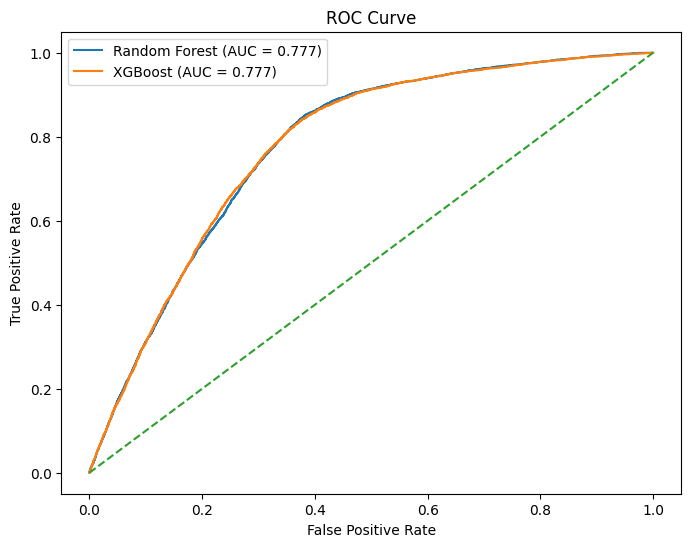

In [13]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

rf_prob = best_rf.predict_proba(x_test)[:, 1]
xgb_prob = best_xgb.predict_proba(x_test)[:, 1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr, rf_tpr,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})'
)

plt.plot(
    xgb_fpr, xgb_tpr,
    label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.3f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Important factors in predicting patient no-shows

In [14]:
rf_model = best_rf.named_steps['classifier']

preprocessor_fitted = best_rf.named_steps['preprocessor']

feature_names = preprocessor_fitted.get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
28,nominal__place_Other,0.251471
66,remainder__max_rain_day,0.094977
21,nominal__place_ITAJAÍ,0.081845
63,remainder__average_temp_day,0.063085
64,remainder__average_rain_day,0.056951
65,remainder__max_temp_day,0.051049
59,remainder__age,0.044595
58,remainder__appointment_time,0.032035
35,nominal__place_unknown,0.025865
18,nominal__place_CAMBORIU,0.023220


According to the Random Forest feature-importance analysis, location and weather-related variables were among the most influential predictors, followed by patient age and appointment-related variables.

### Final Conclusion Matrix

In [15]:
threshold = 0.35

rf_prob = best_rf.predict_proba(x_test)[:, 1]
rf_final_pred = (rf_prob >= threshold).astype(int)

print(confusion_matrix(y_test, rf_final_pred))
print(classification_report(y_test, rf_final_pred))

print("Accuracy:",
      accuracy_score(y_test, rf_final_pred))

print("Precision:",
      precision_score(y_test, rf_final_pred))

print("Recall:",
      recall_score(y_test, rf_final_pred))

print("F1:",
      f1_score(y_test, rf_final_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

[[9136 5816]
 [1006 5961]]
              precision    recall  f1-score   support

           0       0.90      0.61      0.73     14952
           1       0.51      0.86      0.64      6967

    accuracy                           0.69     21919
   macro avg       0.70      0.73      0.68     21919
weighted avg       0.78      0.69      0.70     21919

Accuracy: 0.6887631735024408
Precision: 0.506156066910079
Recall: 0.8556049949763169
F1: 0.6360435339308579
ROC-AUC: 0.7770415062662986


The tuned Random Forest model achieved a ROC-AUC of 0.777, indicating good discrimination between patients who attend and those who miss appointments. After threshold tuning, a probability threshold of 0.35 was selected to prioritize the detection of no-show patients. At this threshold, the model achieved 85.6% recall and an F1-score of 0.636. This means the model successfully identifies approximately 86% of actual no-show cases, although this comes at the cost of a lower precision of 50.6% and accuracy of 68.9%.